In [8]:
from accelerate import Accelerator
import torch

# Accelerator auto-picks mps (Mac), cuda (NVIDIA), or cpu
accelerator = Accelerator()
device = accelerator.device
dtype = torch.float16 if device.type in ("mps", "cuda") else torch.float32

print(f"Using device: {device}, dtype: {dtype}")
print(f"Accelerator mixed precision: {accelerator.mixed_precision}")


Using device: mps, dtype: torch.float16
Accelerator mixed precision: no


In [2]:
# Accelerator is created in the cell above.
# Use accelerator.device (or the `device` variable) when moving models/pipelines.


# 1. Connecting Hugging Face

In [9]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv(override=True)
hf_token = os.getenv("HF_TOKEN")

if not hf_token:
    raise ValueError("HF_TOKEN not found. Add HF_TOKEN=hf_... to your .env file.")

login(hf_token, add_to_git_credential=True)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

/Users/michaelperrine/Documents/Donner/ai-engineer-core-donner/llm_engineering/.venv/lib/python3.12/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


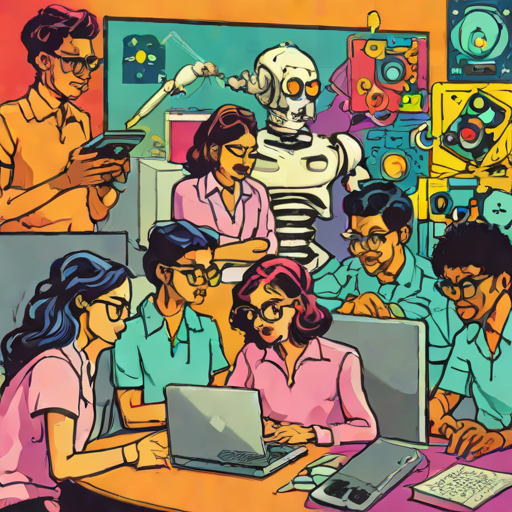

In [4]:
from IPython.display import display
from diffusers import AutoPipelineForText2Image

pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=dtype,
    variant="fp16" if dtype == torch.float16 else None,
)
pipe.to(accelerator.device)  # same as pipe.to(device)

prompt = "A class of students learning AI engineering in a vibrant pop-art style"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
display(image)


In [5]:
import IPython
# IPython.Application.instance().kernel.do_shutdown(True)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


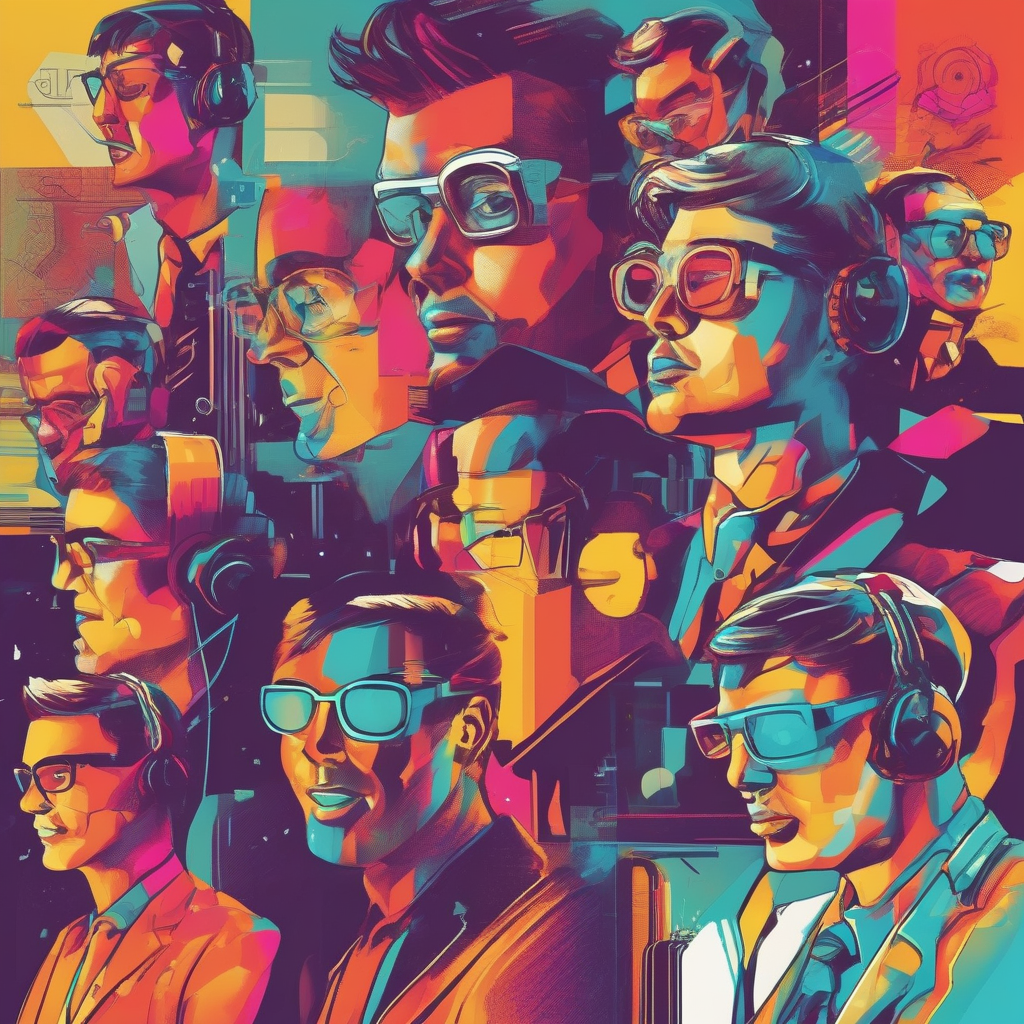

In [6]:
from IPython.display import display
from diffusers import DiffusionPipeline

pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=dtype,
    use_safetensors=True,
    variant="fp16" if dtype == torch.float16 else None,
)
pipe.to(accelerator.device)

prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style"
image = pipe(prompt=prompt, num_inference_steps=30).images[0]
display(image)


In [7]:
import IPython
# IPython.Application.instance().kernel.do_shutdown(True)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

/Users/michaelperrine/Documents/Donner/ai-engineer-core-donner/llm_engineering/.venv/lib/python3.12/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


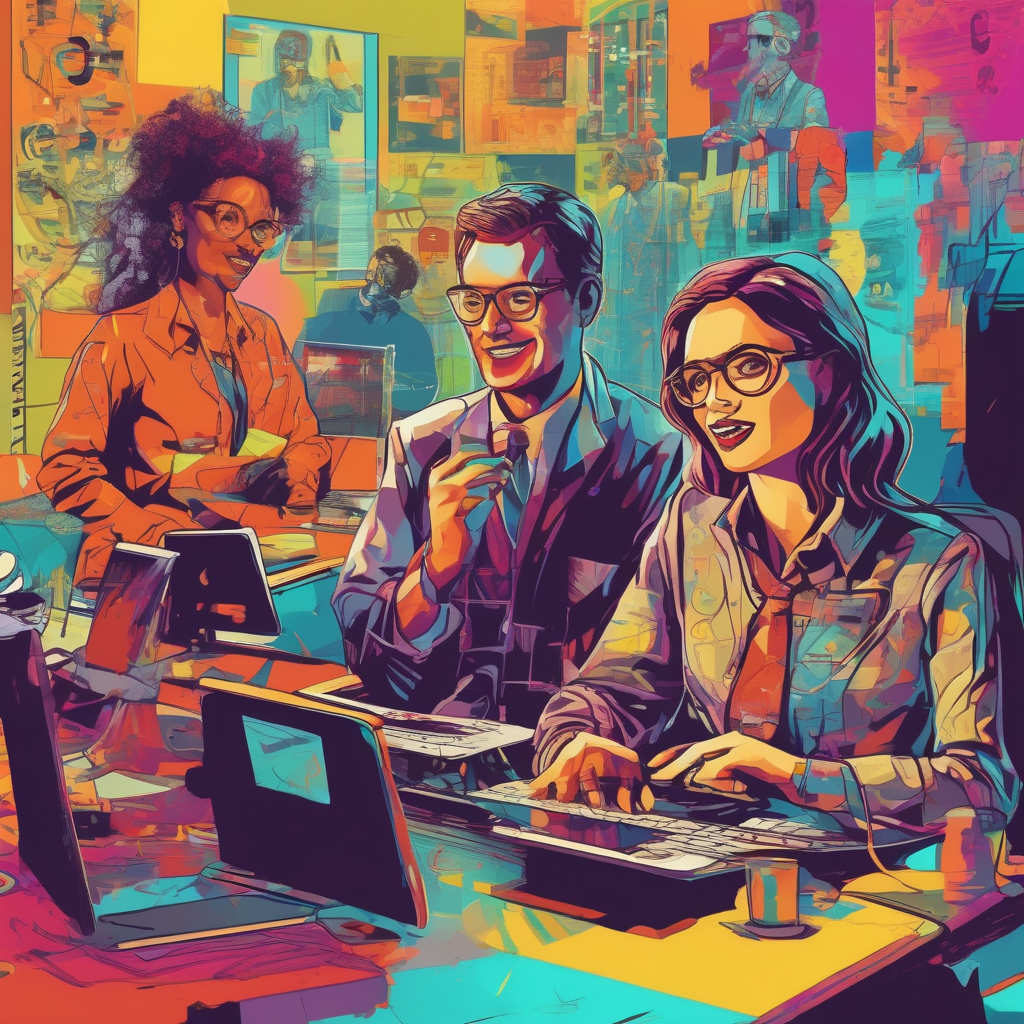

In [8]:
from diffusers import DiffusionPipeline
import torch

base = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0",
                                         torch_dtype = torch.float16,
                                         variant = 'fp16',
                                         use_safetensors = True,
                                         )
base.to(device)

# Define how many steps and what % of steps to be run on each experts (80/20) here
n_steps = 40
high_noise_frac = 0.8

prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style" 

# run both experts
image = base(
    prompt = prompt,
    num_inference_steps = n_steps,
    denoising_start = high_noise_frac,
    image = image,
).images[0]

display(image)

In [9]:
IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

In [1]:
!uv pip install datasets==3.6.0 sentencepiece "huggingface-hub>=0.34.0,<1.0"

Using Python 3.12.12 environment at: /Users/michaelperrine/Documents/Donner/ai-engineer-core-donner/llm_engineering/.venv
Audited 3 packages in 3ms


In [2]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv(override=True)
hf_token = os.getenv("HF_TOKEN")

if not hf_token:
    raise ValueError("HF_TOKEN not found. Add HF_TOKEN=hf_... to your .env file.")

login(hf_token, add_to_git_credential=True)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
from accelerate import Accelerator
import torch

# Accelerator auto-picks mps (Mac), cuda (NVIDIA), or cpu
accelerator = Accelerator()
device = accelerator.device
dtype = torch.float16 if device.type in ("mps", "cuda") else torch.float32

print(f"Using device: {device}, dtype: {dtype}")
print(f"Accelerator mixed precision: {accelerator.mixed_precision}")

Using device: mps, dtype: torch.float16
Accelerator mixed precision: no


In [4]:
from transformers import pipeline
from datasets import load_dataset
import soundfile as sf
import torch
from IPython.display import Audio

# SpeechT5 is unstable on Apple MPS; use CUDA if present, otherwise CPU
tts_device = accelerator.device if accelerator.device.type == "cuda" else "cpu"

syntheiser = pipeline("text-to-speech",
                      "microsoft/speecht5_tts",
                      device=tts_device)
embeddings_dataset = load_dataset("Matthijs/cmu-arctic-xvectors",
                                  split="validation",
                                  trust_remote_code=True)
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)
speech = syntheiser("Hi to an artificial intelligence engineer, on the way to mastery!",
                      forward_params={"speaker_embeddings": speaker_embedding})
Audio(speech["audio"], rate=speech["sampling_rate"])

Device set to use cpu


In [ ]:
import IPython
#IPython.Application.instance().kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

: 

## Requesting access to FLUX.1-schnell

The official model [`black-forest-labs/FLUX.1-schnell`](https://huggingface.co/black-forest-labs/FLUX.1-schnell) is **gated** on Hugging Face. Logging in with `HF_TOKEN` is not enough until your account has been granted access.

1. Open that page while logged into the same Hugging Face account as `HF_TOKEN`.
2. Agree to the terms / request access. Once approved you should see: **You have been granted access to this model**.
3. Re-run the cells below.

If access is not granted yet, the next cell falls back to the ungated Apache-2.0 mirror `unsloth/FLUX.1-schnell` (unmodified weights).

This model is large (~12B parameters). The course Colab targets an A100; on a Mac it may be slow or run out of memory.


In [11]:
import torch
from datetime import datetime

from diffusers import FluxPipeline
from IPython.display import display


model_index.json:   0%|          | 0.00/536 [00:00<?, ?B/s]

Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

text_encoder/model.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

text_encoder_2/model-00001-of-00002.safe(…):   0%|          | 0.00/4.99G [00:00<?, ?B/s]

text_encoder_2/model-00002-of-00002.safe(…):   0%|          | 0.00/4.53G [00:00<?, ?B/s]

...

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

/Users/michaelperrine/Documents/Donner/ai-engineer-core-donner/llm_engineering/.venv/lib/python3.12/site-packages/diffusers/image_processor.py:142: RuntimeWarning: invalid value encountered in cast
  images = (images * 255).round().astype("uint8")


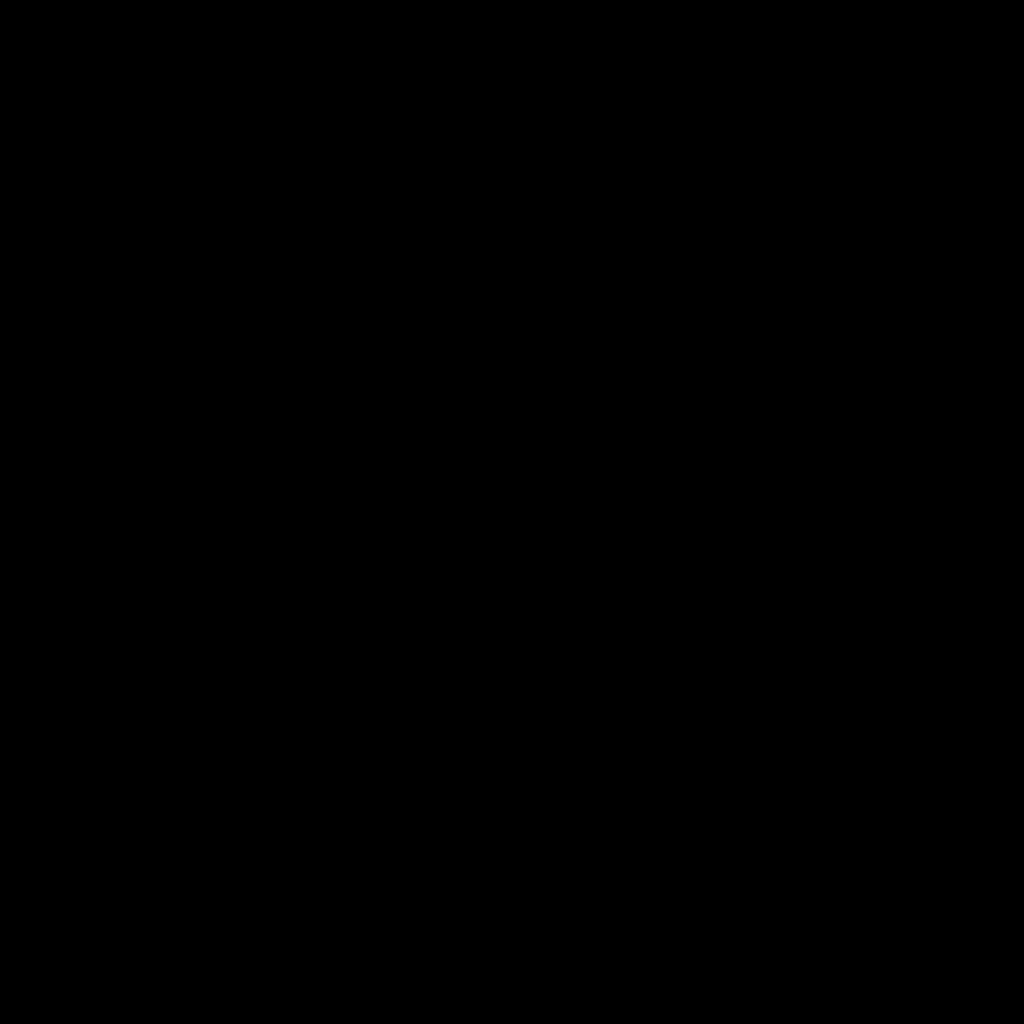

In [12]:
start = datetime.now()

# Official black-forest-labs/FLUX.1-schnell is gated. Use the ungated
# Apache-2.0 mirror (unmodified weights). Request access at
# https://huggingface.co/black-forest-labs/FLUX.1-schnell to use the official repo.
model_id = "unsloth/FLUX.1-schnell"

# FLUX.1-schnell is ~12B params. Use bf16 on CUDA; float16 on MPS/CPU.
flux_dtype = torch.bfloat16 if accelerator.device.type == "cuda" else dtype

pipe = FluxPipeline.from_pretrained(model_id, torch_dtype=flux_dtype).to(accelerator.device)
generator = torch.Generator(device=accelerator.device).manual_seed(0)
prompt = "A class of data scientists learning AI engineering in a vibrant high-energy pop-art style"

image = pipe(
    prompt,
    guidance_scale=0.0,
    num_inference_steps=4,
    max_sequence_length=256,
    generator=generator,
).images[0]

display(image)

stop = datetime.now()


In [13]:
# Cost estimate

seconds = (stop-start).total_seconds()
units_per_hour = 5.37
estimated_units = (5.37 / 3600) * seconds
estimated_cost = estimated_units * (9.99/100)
print(f'This took {seconds:.3f} seconds and cost an estimated ${estimated_cost:.3f}')

This took 665.362 seconds and cost an estimated $0.099
